# LIBRARIES IMPORTATION

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                            confusion_matrix,ConfusionMatrixDisplay, classification_report, 
                            average_precision_score, precision_recall_curve)

import warnings
warnings.filterwarnings("ignore")

In [2]:
pd.set_option("display.max.column", 32)

# DATA IMPORTATION AND AUDITING

In [3]:
fraud = pd.read_csv("../creditcard.csv")
fraud.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
fraud.shape

(284807, 31)

In [5]:
fraud.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
fraud.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
fraud.duplicated().sum()

np.int64(1081)

In [8]:
fraud[["Time", "Amount"]].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


### Insight

The dataset contains **284,807 transaction records and 31 columns**. Of these, **28 columns (V1–V28)** contain anonymized numerical features, while **Time**, **Amount**, and **Class** provide additional information about each transaction. The **Time** column represents the number of seconds elapsed between each transaction and the first transaction in the dataset. The **Amount** column indicates the monetary value of each transaction, while the **Class** column identifies whether a transaction is **legitimate (non-fraudulent)** or **fraudulent**.

The dataset contains **no missing values**, indicating that all records have complete information across the available features. However, approximately **1,081 duplicate records** were identified, which will be removeed during the data-cleaning stage to avoid potential bias in the analysis.


In [9]:
df = fraud.copy()

# Data cleaning

In [10]:
df.drop_duplicates(inplace = True)

# Analysis

In [11]:
class_perc = df["Class"].value_counts(normalize = True) * 100
class_perc

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

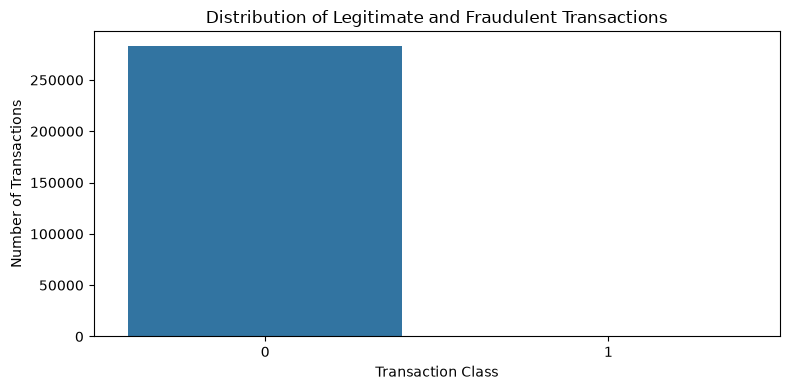

In [12]:
plt.figure(figsize = (8, 4))
sns.countplot(data = df, x = "Class")
plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

### Insight: Fraud Rate

The dataset is **highly imbalanced**. Approximately **99.83% of the transactions are legitimate (Class 0)**, while only **0.17% are fraudulent (Class 1)**. This means fraudulent transactions make up a very small proportion of the dataset.

In [13]:
# Convert time to hours (0-23)
df["Hour"] = (df["Time"] // 3600) % 24

In [14]:
df["Hour"].tail()

284802    23.0
284803    23.0
284804    23.0
284805    23.0
284806    23.0
Name: Hour, dtype: float64

In [15]:
# Looking at transaction hours 
hourly_trans = (df.groupby("Hour").size()
                .reset_index(name = "Transaction_Count")
                 .sort_values("Transaction_Count", ascending=False))
hourly_trans

,Hour,Transaction_Count
21,21.0,17629
18,18.0,16959
11,11.0,16781
20,20.0,16705
10,10.0,16548
14,14.0,16520
16,16.0,16396
15,15.0,16374
17,17.0,16130
9,9.0,15767


### Insight

The highest number of transactions occurred at **Hour 21**, with a total of **17,629 transactions**. This indicates that Hour 21 had the highest transaction volume in the dataset.


In [16]:
fraud_by_hour = (
    df.groupby("Hour")["Class"].mean().mul(100)
      .reset_index(name="Fraud_Rate")
      .sort_values("Fraud_Rate", ascending=False))
fraud_by_hour

,Hour,Fraud_Rate
2,2.0,1.451028
4,4.0,1.043557
3,3.0,0.487525
5,5.0,0.368139
7,7.0,0.317987
11,11.0,0.315833
1,1.0,0.237643
6,6.0,0.220480
17,17.0,0.173590
18,18.0,0.165104


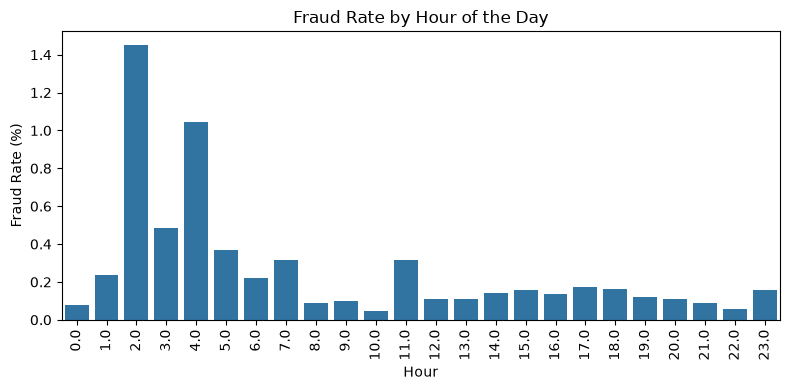

In [17]:
plt.figure(figsize=(8, 4))
sns.barplot(data = fraud_by_hour, x = "Hour", y = "Fraud_Rate")
plt.title("Fraud Rate by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

### Insight: Fraud Rate by Hour

Fraud rates varied across hours, with the **highest rate at Hour 2 (1.45%)** and the **lowest at Hour 10 (0.05%)**. This suggests that fraud occurrence was not evenly distributed across the observed time periods.


In [18]:
# comparing transaction amounts for fraudulent vs. legitimate transactions.
trans_amount = df.groupby("Class")["Amount"].describe()
trans_amount

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


### Insight
Fraudulent transactions have a higher average amount (123.87) than legitimate transactions (88.41), but a lower median amount (9.82 vs. 22.00). This suggests that fraudulent transaction amounts are highly variable, with a few unusually large transactions increasing the average.


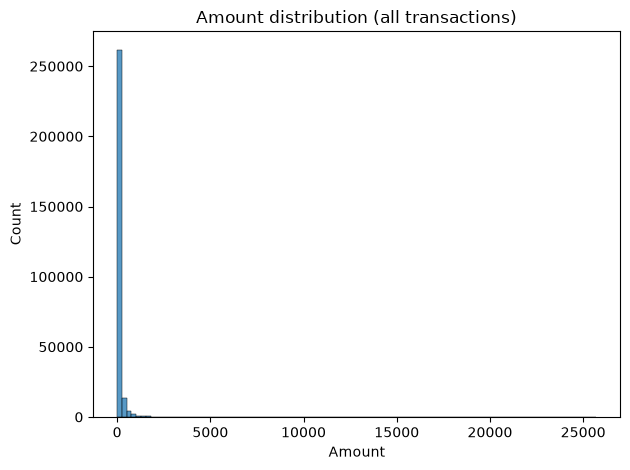

In [19]:
sns.histplot(df["Amount"], bins=100)
plt.title("Amount distribution (all transactions)")
plt.tight_layout()
plt.show()


# Insight:
Amount is right skewed which most transactions are smaller and there are few larger transactions.

# DATA PREPROCESSING

In [20]:
X = df.drop(columns = ["Class", "Hour"])
y = df["Class"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, 
                                                   random_state = 42, stratify = y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape) 

(198608, 30) (85118, 30) (198608,) (85118,)


In [22]:
scaler = StandardScaler()

In [23]:
X_train[["Amount", "Time"]] = scaler.fit_transform(X_train[["Amount", "Time"]]) 
X_test[["Amount", "Time"]] = scaler.transform(X_test[["Amount", "Time"]])

In [24]:
print(y_train.value_counts(normalize=True) * 100)
print(y_test.value_counts(normalize=True) * 100)

Class
0    99.83334
1     0.16666
Name: proportion, dtype: float64
Class
0    99.833173
1     0.166827
Name: proportion, dtype: float64


# MODEL DEFINITION

In [25]:
models = {
    "LogReg" : lambda cw = None: LogisticRegression(max_iter = 2000, 
                                                   class_weight = cw, random_state = 42),
    "DecisionTree" : lambda cw = None: DecisionTreeClassifier(max_depth = 8, min_samples_leaf = 5,
                                                   class_weight = cw, random_state = 42),
    "RandomForest" : lambda cw = None: RandomForestClassifier(n_estimators = 200, n_jobs = -1, 
                                                   class_weight = cw, random_state = 42)
}

# PIPELINE

In [26]:
pipelines = {}

for model_name, create_model in models.items():
    # Baseline
    pipelines[f"{model_name} | baseline"] = Pipeline([("clf", create_model())])
    # Class weight
    pipelines[f"{model_name} | class_weight"] = Pipeline([("clf", create_model("balanced"))])
    # Smote and undersampling
    pipelines[f"{model_name} | smote"] = Pipeline([("smote", SMOTE(sampling_strategy = 0.1, 
                                                            k_neighbors = 3, random_state = 42)), 
                                            
                                        ("under", RandomUnderSampler(sampling_strategy = 0.5,
                                            random_state = 42)), ("clf", create_model())])

For each model, the function for creating the model, control how much importance is given to each class. Storing all the model to a pipeline where clf is the classifier.

In [ ]:
# splitting the training into 5 parts.
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

scoring = {"pr_auc": "average_precision",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1"}
# Store result
rows = []
for model_name, pipeline in pipelines.items():
    cv_results = cross_validate(pipeline, X_train, y_train, cv = cv, scoring = scoring, n_jobs = -1)
    rows.append({
        "config": model_name,
        "pr_auc": cv_results["test_pr_auc"].mean(),
        "recall": cv_results["test_recall"].mean(),
        "precision": cv_results["test_precision"].mean(),
        "f1": cv_results["test_f1"].mean()
    })
results = pd.DataFrame(rows)
results = results.sort_value ("pr_auc", ascending = False)